In [128]:
import csv
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression, Lasso, Ridge
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.feature_selection import (
    mutual_info_classif, 
    f_classif,
    SelectKBest, 
    SelectFromModel,
    RFE
)
from matplotlib import pyplot as plt
import seaborn as sns

In [126]:
# load data
data = pd.read_csv('data.csv', header=None)
feature_names = pd.read_csv('feature_names.csv', header=None)
labels = pd.read_csv('labels.csv', header=None)

,0,1,2,3,4,5,6,7,8,9,...,422,423,424,425,426,427,428,429,430,431
0,alpha_ec_0,alpha_ec_1,alpha_ec_2,alpha_ec_3,alpha_ec_4,alpha_ec_5,alpha_ec_6,alpha_ec_7,alpha_ec_8,alpha_ec_9,...,ratio_theta_38,ratio_theta_39,ratio_theta_40,ratio_theta_41,ratio_theta_42,ratio_theta_43,ratio_theta_44,ratio_theta_45,ratio_theta_46,ratio_theta_47


In [344]:
# prepare data for machine learning
X = data.to_numpy()
y = labels.to_numpy().ravel()


In [4]:
#create groups for cross validation
groups = np.repeat(np.arange(18), 10)

In [303]:
# Define classifiers
def create_classifiers():
    return {
        'SVM': SVC(kernel='linear', C=10),
        'Random Forest': RandomForestClassifier(n_estimators=100),
        'Naive Bayes': GaussianNB(),
        'Logistic Regression': LogisticRegression(max_iter=10000, penalty=None)  #so that it doesn't use a regularizer by default   
    }

In [304]:
#Model evaluation function

def evaluate_model(X, y, groups, classifier):
    #create pipeline
    pipeline = Pipeline([
        ('classifier', classifier)
    ])

    #perform leave one group out cross validation
    logo = LeaveOneGroupOut()

    #collect performance metrics
    accuracies = []
    sensitivities = []
    specificities = []

    for train_index, test_index in logo.split(X, y, groups):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        # calculate metrics
        cm = confusion_matrix(y_test, y_pred, labels=[0,1])
        tn, fp, fn, tp = cm.ravel()
        accuracies.append(accuracy_score(y_test, y_pred))
        sensitivities.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

    return {
        'accuracy': np.mean(accuracies),
        'sensitivity': np.mean(sensitivities),
        'specificity': np.mean(specificities),
        'accuracy_std': np.std(accuracies),
        'sensitivity_std': np.std(sensitivities),
        'specificity_std': np.std(specificities),
    }

In [305]:
# Baseline Full Feature Set Performance
print("Baseline performance:")
baseline_classifiers = create_classifiers()
for name, clf in baseline_classifiers.items():
    baseline_results = evaluate_model(X_hypothesis, y, groups, classifier=clf)
    print(f"{name}: {baseline_results}")



Baseline performance:
SVM: {'accuracy': 0.9166666666666666, 'sensitivity': 0.4000000000000001, 'specificity': 0.5166666666666667, 'accuracy_std': 0.10137937550497032, 'sensitivity_std': 0.45215533220835125, 'specificity_std': 0.46815239683960463}
Random Forest: {'accuracy': 0.7888888888888889, 'sensitivity': 0.3111111111111111, 'specificity': 0.47777777777777775, 'accuracy_std': 0.14098419489388359, 'sensitivity_std': 0.3541639433446495, 'specificity_std': 0.4378680110052896}
Naive Bayes: {'accuracy': 0.6333333333333333, 'sensitivity': 0.2833333333333334, 'specificity': 0.35000000000000003, 'accuracy_std': 0.10540925533894599, 'sensitivity_std': 0.3270236145058097, 'specificity_std': 0.32015621187164245}
Logistic Regression: {'accuracy': 0.911111111111111, 'sensitivity': 0.39444444444444443, 'specificity': 0.5166666666666666, 'accuracy_std': 0.09362388636862622, 'sensitivity_std': 0.44531165394114997, 'specificity_std': 0.46696419087073}


In [273]:
print(sensitivities)

0.13286956381223777 0.3961231882216864 0.4268749491621899
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.9, 0.5, 0.8, 0.9, 0.8, 0.6, 0.8, 0.9]


In [272]:
groups

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       17, 17, 17, 17, 17, 17, 17, 17, 17, 17])

In [123]:
def analyze_anova_features(X, y, feature_names):
    f_scores, p_values = f_classif(X, y)
    anova_df = pd.DataFrame({
        'feature': feature_names.T.ravel(),
        'f_score': f_scores,
        'p_value': p_values
    }).sort_values('f_score', ascending=False)
    
    return anova_df

In [124]:
df = analyze_anova_features(X, y, feature_names)
df.head(30)

,feature,f_score,p_value
370,ratio_beta_34,50.515116,2.752280e-11
371,ratio_beta_35,40.234428,1.804678e-09
373,ratio_beta_37,39.018106,3.003193e-09
340,ratio_beta_4,38.338915,3.996680e-09
338,ratio_beta_2,30.927975,9.676000e-08
336,ratio_beta_0,30.728207,1.056311e-07
365,ratio_beta_29,28.954990,2.311377e-07
383,ratio_beta_47,27.863695,3.757691e-07
25,alpha_ec_25,26.664689,6.432640e-07
357,ratio_beta_21,26.368838,7.349493e-07


C:\Users\praty\AppData\Local\Temp\ipykernel_5728\1126928055.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='f_score', y='feature', data=df.head(30),


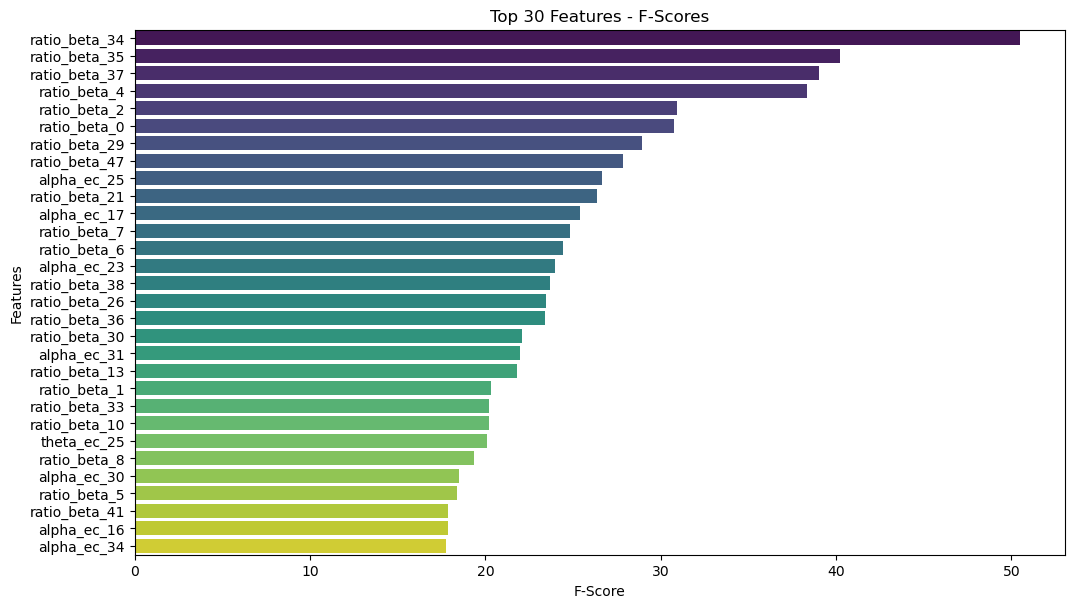

In [133]:
plt.figure(figsize=(12,15))
plt.subplot(2, 1, 1)
sns.barplot(x='f_score', y='feature', data=df.head(30), 
                palette='viridis')
plt.title(f'Top {30} Features - F-Scores')
plt.xlabel('F-Score')
plt.ylabel('Features')
plt.show()

In [291]:
#Model evaluation function

def evaluate_model_anova(X, y, groups, classifier, k):
    #create pipeline
    pipeline = Pipeline([
        ('classifier', classifier)
    ])

    #perform leave one group out cross validation
    logo = LeaveOneGroupOut()

    #collect performance metrics
    accuracies = []
    sensitivities = []
    specificities = []

    for train_index, test_index in logo.split(X, y, groups):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        selector = SelectKBest(score_func=f_classif, k=k)
        X_train_new = selector.fit_transform(X_train, y_train)

        #get mask of selected features
        feature_mask = selector.get_support()
        X_test_new = X_test[:, feature_mask]


        pipeline.fit(X_train_new, y_train)
        y_pred = pipeline.predict(X_test_new)

        # calculate metrics
        cm = confusion_matrix(y_test, y_pred, labels=[0,1])
        tn, fp, fn, tp = cm.ravel()

        accuracies.append(accuracy_score(y_test, y_pred))
        sensitivities.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

    return {
        'accuracy': np.mean(accuracies),
        'sensitivity': np.mean(sensitivities),
        'specificity': np.mean(specificities),
        'accuracy_std': np.std(accuracies),
        'sensitivity_std': np.std(sensitivities),
        'specificity_std': np.std(specificities),
    }

In [293]:
# Baseline Full Feature Set Performance
print("Anova performance:")
classifiers = create_classifiers()
best_svm_accuracy = 0
best_lr_accuracy = 0
best_nb_accuracy = 0
best_rf_accuracy = 0

best_k_svm = 0
best_k_lr = 0
best_k_nb = 0
best_k_rf = 0
for i in [60,100,120,150,200]:
    for name, clf in baseline_classifiers.items():
        anova_results = evaluate_model_anova(X, y, groups, classifier=clf, k=i)
        print(f"{name}: {anova_results} at k={i}")
        if name == 'SVM' and anova_results['accuracy'] > best_svm_accuracy:
            best_k_svm = i
            best_svm_accuracy = anova_results['accuracy']
        if name == 'Random Forest' and anova_results['accuracy'] > best_rf_accuracy:
            best_k_rf = i
            best_rf_accuracy = anova_results['accuracy']
        if name == 'Logistic Regression' and anova_results['accuracy'] > best_lr_accuracy:
            best_k_lr = i
            best_lr_accuracy = anova_results['accuracy']
        if name == 'Naive Bayes' and anova_results['accuracy'] > best_nb_accuracy:
            best_k_nb = i
            best_nb_accuracy = anova_results['accuracy']

print(f"Best SVM Accuracy: {best_svm_accuracy} at {best_k_svm}")
print(f"Best LR Accuracy: {best_lr_accuracy} at {best_k_lr}")
print(f"Best NB Accuracy: {best_nb_accuracy} at {best_k_nb}")
print(f"Best RF Accuracy: {best_rf_accuracy} at {best_k_rf}")

Anova performance:
SVM: {'accuracy': 0.838888888888889, 'sensitivity': 0.3611111111111111, 'specificity': 0.47777777777777786, 'accuracy_std': 0.11124991330278215, 'sensitivity_std': 0.40843725057139557, 'specificity_std': 0.4365973934308556} at k=60
Random Forest: {'accuracy': 0.7444444444444445, 'sensitivity': 0.30000000000000004, 'specificity': 0.4444444444444444, 'accuracy_std': 0.13833221775543036, 'sensitivity_std': 0.34318767136623335, 'specificity_std': 0.4099081499043715} at k=60
Naive Bayes: {'accuracy': 0.6944444444444443, 'sensitivity': 0.25, 'specificity': 0.4444444444444444, 'accuracy_std': 0.14326441064697365, 'sensitivity_std': 0.2813657169355689, 'specificity_std': 0.4044505494044732} at k=60
Logistic Regression: {'accuracy': 0.8166666666666668, 'sensitivity': 0.3666666666666667, 'specificity': 0.44999999999999996, 'accuracy_std': 0.14624940645653536, 'sensitivity_std': 0.41633319989322654, 'specificity_std': 0.42196629670573876} at k=60
SVM: {'accuracy': 0.89444444444

## Feature Selection using Recursive Feature Elimination(RFE)

In [334]:
#Model evaluation function

def evaluate_model_rfe(X, y, groups, classifier, estimator, k):
    #create pipeline
    pipeline = Pipeline([
        ('classifier', classifier)
    ])

    #perform leave one group out cross validation
    logo = LeaveOneGroupOut()

    #collect performance metrics
    accuracies = []
    sensitivities = []
    specificities = []

    for train_index, test_index in logo.split(X, y, groups):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        selector = RFE(estimator=estimator, n_features_to_select=k)
        selector.fit(X_train, y_train)

        X_train_new = selector.transform(X_train)
        X_test_new = selector.transform(X_test)
        

        pipeline.fit(X_train_new, y_train)
        y_pred = pipeline.predict(X_test_new)

        # calculate metrics
        cm = confusion_matrix(y_test, y_pred, labels=[0,1])
        tn, fp, fn, tp = cm.ravel()

        accuracies.append(accuracy_score(y_test, y_pred))
        sensitivities.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

    return {
        'accuracy': np.mean(accuracies),
        'sensitivity': np.mean(sensitivities),
        'specificity': np.mean(specificities),
        'accuracy_std': np.std(accuracies),
        'sensitivity_std': np.std(sensitivities),
        'specificity_std': np.std(specificities),
    }

In [335]:
#RFE performance varying k
print("RFE:")
classifiers = create_classifiers()
best_svm_accuracy = 0
best_lr_accuracy = 0
best_nb_accuracy = 0
best_rf_accuracy = 0

best_k_svm = 0
best_k_lr = 0
best_k_nb = 0
best_k_rf = 0
for i in [60,100,120,150,200]:
    for name, clf in baseline_classifiers.items():
        rfe_results = evaluate_model_rfe(X, y, groups, classifier=clf, estimator=SVC(kernel='linear', C=10), k=i)
        print(f"{name}: {rfe_results} at k={i}")
        if name == 'SVM' and rfe_results['accuracy'] > best_svm_accuracy:
            best_k_svm = i
            best_svm_accuracy = rfe_results['accuracy']
        if name == 'Random Forest' and rfe_results['accuracy'] > best_rf_accuracy:
            best_k_rf = i
            best_rf_accuracy = rfe_results['accuracy']
        if name == 'Logistic Regression' and rfe_results['accuracy'] > best_lr_accuracy:
            best_k_lr = i
            best_lr_accuracy = rfe_results['accuracy']
        if name == 'Naive Bayes' and rfe_results['accuracy'] > best_nb_accuracy:
            best_k_nb = i
            best_nb_accuracy = rfe_results['accuracy']

print(f"Best SVM Accuracy: {best_svm_accuracy} at {best_k_svm}")
print(f"Best LR Accuracy: {best_lr_accuracy} at {best_k_lr}")
print(f"Best NB Accuracy: {best_nb_accuracy} at {best_k_nb}")
print(f"Best RF Accuracy: {best_rf_accuracy} at {best_k_rf}")

RFE:
SVM: {'accuracy': 0.8111111111111111, 'sensitivity': 0.3277777777777777, 'specificity': 0.4833333333333333, 'accuracy_std': 0.14487116456005888, 'sensitivity_std': 0.37830845080518266, 'specificity_std': 0.4412734098291242} at k=60
Random Forest: {'accuracy': 0.838888888888889, 'sensitivity': 0.35555555555555557, 'specificity': 0.4833333333333333, 'accuracy_std': 0.09509579315902052, 'sensitivity_std': 0.4003085229922627, 'specificity_std': 0.4387482193696061} at k=60
Naive Bayes: {'accuracy': 0.7388888888888888, 'sensitivity': 0.27222222222222225, 'specificity': 0.4666666666666667, 'accuracy_std': 0.14958791130929178, 'sensitivity_std': 0.30877096070200566, 'specificity_std': 0.4255715111601235} at k=60
Logistic Regression: {'accuracy': 0.8388888888888889, 'sensitivity': 0.3388888888888889, 'specificity': 0.5, 'accuracy_std': 0.13799713720415802, 'sensitivity_std': 0.39035438156869273, 'specificity_std': 0.45338235029118146} at k=60
SVM: {'accuracy': 0.811111111111111, 'sensitivi

In [327]:
#RFE performance varying k
print("RFE:")
classifiers = create_classifiers()
best_svm_accuracy = 0
best_lr_accuracy = 0
best_nb_accuracy = 0
best_rf_accuracy = 0

best_k_svm = 0
best_k_lr = 0
best_k_nb = 0
best_k_rf = 0
for i in [5,10,20,30]:
    for name, clf in baseline_classifiers.items():
        rfe_results = evaluate_model_rfe(X, y, groups, classifier=clf, estimator=estimator, k=i)
        print(f"{name}: {rfe_results} at k={i}")
        if name == 'SVM' and rfe_results['accuracy'] > best_svm_accuracy:
            best_k_svm = i
            best_svm_accuracy = rfe_results['accuracy']
        if name == 'Random Forest' and rfe_results['accuracy'] > best_rf_accuracy:
            best_k_rf = i
            best_rf_accuracy = rfe_results['accuracy']
        if name == 'Logistic Regression' and rfe_results['accuracy'] > best_lr_accuracy:
            best_k_lr = i
            best_lr_accuracy = rfe_results['accuracy']
        if name == 'Naive Bayes' and rfe_results['accuracy'] > best_nb_accuracy:
            best_k_nb = i
            best_nb_accuracy = rfe_results['accuracy']

print(f"Best SVM Accuracy: {best_svm_accuracy} at {best_k_svm}")
print(f"Best LR Accuracy: {best_lr_accuracy} at {best_k_lr}")
print(f"Best NB Accuracy: {best_nb_accuracy} at {best_k_nb}")
print(f"Best RF Accuracy: {best_rf_accuracy} at {best_k_rf}")

RFE:
SVM: {'accuracy': 0.8222222222222223, 'sensitivity': 0.3388888888888889, 'specificity': 0.4833333333333334, 'accuracy_std': 0.1356283957303745, 'sensitivity_std': 0.3903543815686927, 'specificity_std': 0.4400126260814695} at k=5
Random Forest: {'accuracy': 0.8333333333333334, 'sensitivity': 0.35000000000000003, 'specificity': 0.4833333333333333, 'accuracy_std': 0.12018504251546633, 'sensitivity_std': 0.3989569734528608, 'specificity_std': 0.4400126260814695} at k=5
Naive Bayes: {'accuracy': 0.7722222222222223, 'sensitivity': 0.28888888888888886, 'specificity': 0.4833333333333334, 'accuracy_std': 0.15565473029024335, 'sensitivity_std': 0.3348115371848747, 'specificity_std': 0.43748015828022296} at k=5
Logistic Regression: {'accuracy': 0.8277777777777778, 'sensitivity': 0.3277777777777778, 'specificity': 0.5, 'accuracy_std': 0.13664859862498713, 'sensitivity_std': 0.3753599095913082, 'specificity_std': 0.45338235029118146} at k=5
SVM: {'accuracy': 0.8222222222222223, 'sensitivity': 

KeyboardInterrupt: 

In [332]:
# Define estimators
def create_estimators():
    return {
        'Random Forest': RandomForestClassifier(n_estimators=100),
        'Logistic Regression': LogisticRegression(max_iter=10000, penalty=None)  #so that it doesn't use a regularizer by default   
    }

In [333]:
#RFE performance varying estimators
print("RFE:")
classifiers = create_classifiers()
estimators = create_estimators()
best_svm_accuracy = 0
best_lr_accuracy = 0
best_nb_accuracy = 0
best_rf_accuracy = 0

for e_name, estimator in estimators.items():
    for name, clf in classifiers.items():
        rfe_results = evaluate_model_rfe(X, y, groups, classifier=clf, estimator=estimator, k=5)
        print(f"{name}: {rfe_results} with estimator={e_name}")
        if name == 'SVM' and rfe_results['accuracy'] > best_svm_accuracy:
            best_svm_accuracy = rfe_results['accuracy']
        if name == 'Random Forest' and rfe_results['accuracy'] > best_rf_accuracy:
            best_rf_accuracy = rfe_results['accuracy']
        if name == 'Logistic Regression' and rfe_results['accuracy'] > best_lr_accuracy:
            best_lr_accuracy = rfe_results['accuracy']
        if name == 'Naive Bayes' and rfe_results['accuracy'] > best_nb_accuracy:
            best_nb_accuracy = rfe_results['accuracy']

print(f"Best SVM Accuracy: {best_svm_accuracy}")
print(f"Best LR Accuracy: {best_lr_accuracy}")
print(f"Best NB Accuracy: {best_nb_accuracy} ")
print(f"Best RF Accuracy: {best_rf_accuracy}")

RFE:
SVM: {'accuracy': 0.8222222222222223, 'sensitivity': 0.3388888888888889, 'specificity': 0.4833333333333334, 'accuracy_std': 0.1356283957303745, 'sensitivity_std': 0.3903543815686927, 'specificity_std': 0.4400126260814695} with estimator=Random Forest
Random Forest: {'accuracy': 0.8166666666666668, 'sensitivity': 0.3388888888888889, 'specificity': 0.47777777777777775, 'accuracy_std': 0.12133516482134199, 'sensitivity_std': 0.38606114784648193, 'specificity_std': 0.4353230672035496} with estimator=Random Forest
Naive Bayes: {'accuracy': 0.7722222222222223, 'sensitivity': 0.28888888888888886, 'specificity': 0.4833333333333334, 'accuracy_std': 0.15565473029024335, 'sensitivity_std': 0.3348115371848747, 'specificity_std': 0.43748015828022296} with estimator=Random Forest
Logistic Regression: {'accuracy': 0.8277777777777778, 'sensitivity': 0.3277777777777778, 'specificity': 0.5, 'accuracy_std': 0.13664859862498713, 'sensitivity_std': 0.3753599095913082, 'specificity_std': 0.453382350291

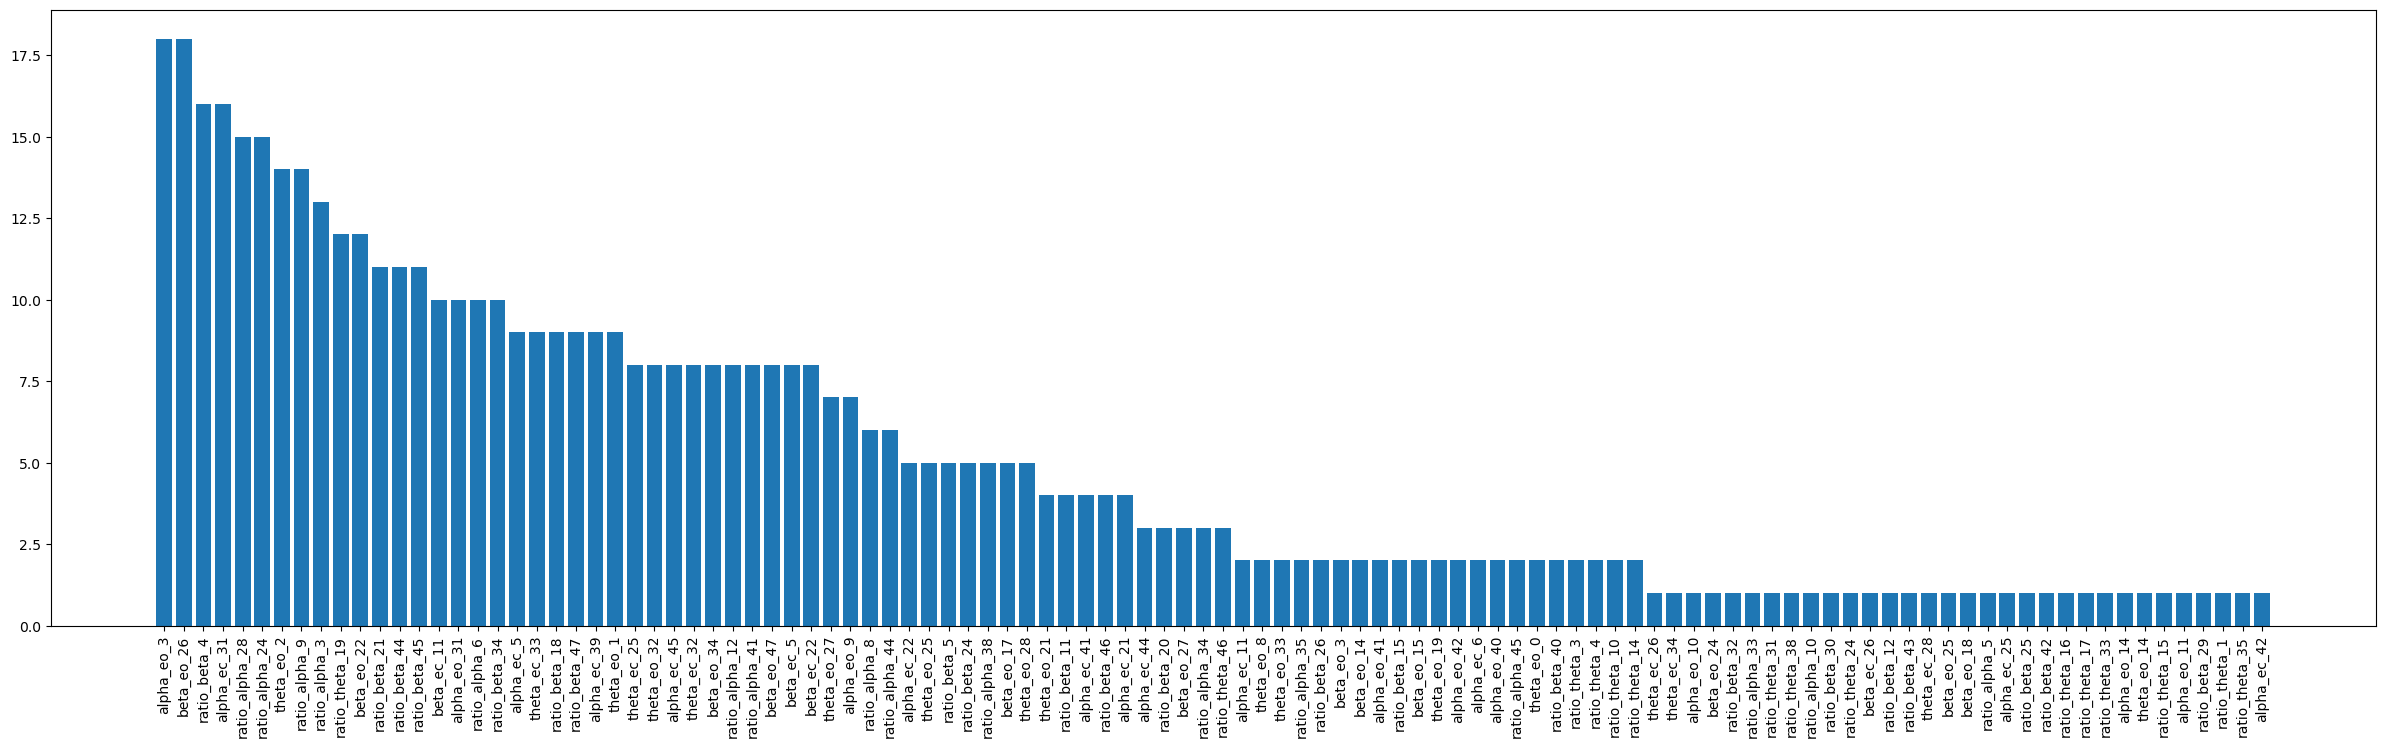

In [206]:
feature_frequency = dict(sorted(feature_frequency.items(), key=lambda item: item[1], reverse=True))

names = list(feature_frequency.keys())
values = list(feature_frequency.values())
plt.figure(figsize=(30,8))
plt.bar(range(len(feature_frequency)), values, tick_label=names)
plt.xticks(rotation=90)
plt.show()

# Mutual Info

## Run Mutual Info on entire dataset

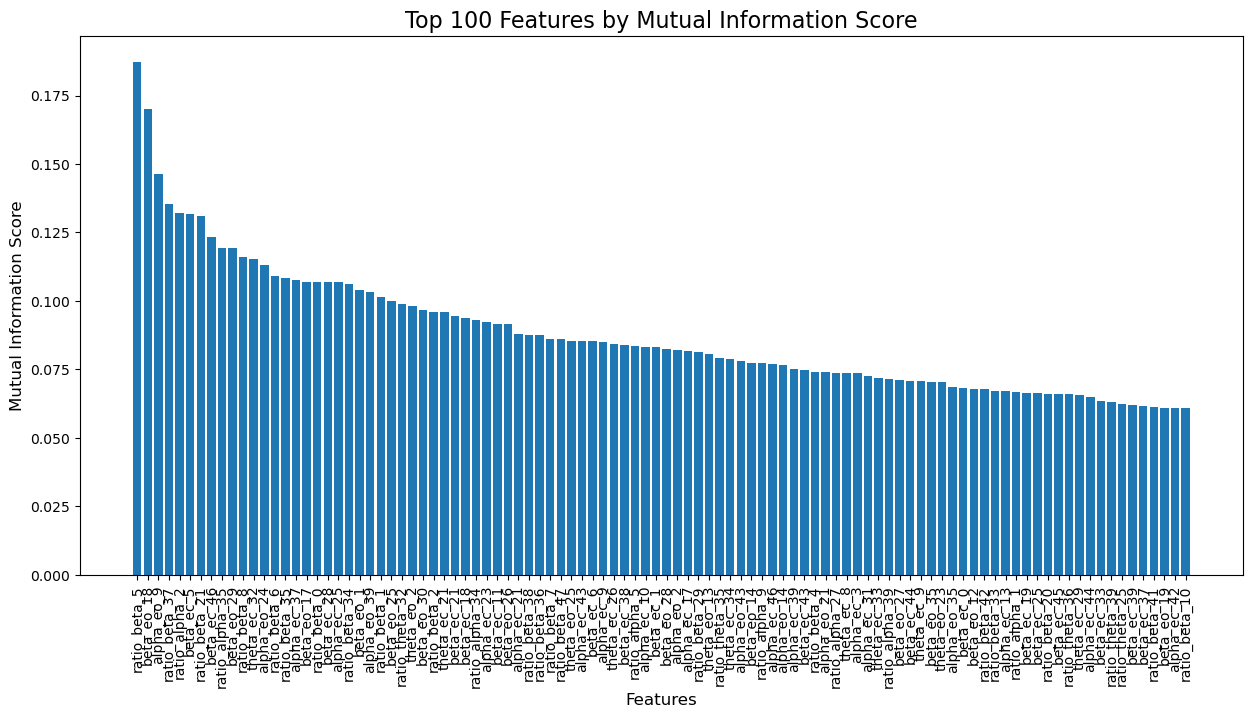

In [249]:
mi_scores = mutual_info_classif(X, y)

# Get features sorted by their mutual information score
sorted_features = sorted(
    zip(feature_names.T, mi_scores), 
    key=lambda x: x[1], 
    reverse=True
)

# Top 100 features with their scores
top_100_features = sorted_features[:100]
feature_names_top100 = [feature[0].tolist()[0] for feature in top_100_features]
scores_top100 = [feature[1] for feature in top_100_features]


# Create the bar plot

plt.figure(figsize=(15, 7))
plt.bar(feature_names_top100, scores_top100)
plt.title('Top 100 Features by Mutual Information Score', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Mutual Information Score', fontsize=12)
plt.xticks(rotation=90) 
plt.show()

In [285]:
#Model evaluation function

def evaluate_model_mutual_info(X, y, groups, classifier, k):
    #create pipeline
    pipeline = Pipeline([
        ('classifier', classifier)
    ])

    #perform leave one group out cross validation
    logo = LeaveOneGroupOut()

    #collect performance metrics
    accuracies = []
    sensitivities = []
    specificities = []

    for train_index, test_index in logo.split(X, y, groups):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        selector = SelectKBest(score_func=mutual_info_classif, k=k)
        X_train_new = selector.fit_transform(X_train, y_train)

        #get mask of selected features
        feature_mask = selector.get_support()
        X_test_new = X_test[:, feature_mask]


        pipeline.fit(X_train_new, y_train)
        y_pred = pipeline.predict(X_test_new)

        # calculate metrics
        cm = confusion_matrix(y_test, y_pred, labels=[0,1])
        tn, fp, fn, tp = cm.ravel()

        accuracies.append(accuracy_score(y_test, y_pred))
        sensitivities.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

    return {
        'accuracy': np.mean(accuracies),
        'sensitivity': np.mean(sensitivities),
        'specificity': np.mean(specificities),
        'accuracy_std': np.std(accuracies),
        'sensitivity_std': np.std(sensitivities),
        'specificity_std': np.std(specificities),
    }

In [290]:
#Mutual info performance varying k
print("mutual info performance:")
classifiers = create_classifiers()
best_svm_accuracy = 0
best_lr_accuracy = 0
best_nb_accuracy = 0
best_rf_accuracy = 0

best_k_svm = 0
best_k_lr = 0
best_k_nb = 0
best_k_rf = 0
for i in [60,100,120,150,200]:
    for name, clf in baseline_classifiers.items():
        mutual_info_results = evaluate_model_mutual_info(X, y, groups, classifier=clf, k=i)
        print(f"{name}: {mutual_info_results} at k={i}")
        if name == 'SVM' and mutual_info_results['accuracy'] > best_svm_accuracy:
            best_k_svm = i
            best_svm_accuracy = mutual_info_results['accuracy']
        if name == 'Random Forest' and mutual_info_results['accuracy'] > best_rf_accuracy:
            best_k_rf = i
            best_rf_accuracy = mutual_info_results['accuracy']
        if name == 'Logistic Regression' and mutual_info_results['accuracy'] > best_lr_accuracy:
            best_k_lr = i
            best_lr_accuracy = mutual_info_results['accuracy']
        if name == 'Naive Bayes' and mutual_info_results['accuracy'] > best_nb_accuracy:
            best_k_nb = i
            best_nb_accuracy = mutual_info_results['accuracy']

print(f"Best SVM Accuracy: {best_svm_accuracy} at {best_k_svm}")
print(f"Best LR Accuracy: {best_lr_accuracy} at {best_k_lr}")
print(f"Best NB Accuracy: {best_nb_accuracy} at {best_k_nb}")
print(f"Best RF Accuracy: {best_rf_accuracy} at {best_k_rf}")

mutual info performance:
SVM: {'accuracy': 0.8666666666666667, 'sensitivity': 0.3666666666666667, 'specificity': 0.5, 'accuracy_std': 0.11055415967851334, 'sensitivity_std': 0.4216370213557839, 'specificity_std': 0.44845413490245706} at k=60
Random Forest: {'accuracy': 0.8000000000000002, 'sensitivity': 0.35, 'specificity': 0.45000000000000007, 'accuracy_std': 0.11547005383792518, 'sensitivity_std': 0.39616214413349043, 'specificity_std': 0.41399141161247405} at k=60
Naive Bayes: {'accuracy': 0.7555555555555556, 'sensitivity': 0.28888888888888886, 'specificity': 0.4666666666666667, 'accuracy_std': 0.1165343164633502, 'sensitivity_std': 0.3264095738126307, 'specificity_std': 0.42031734043061636} at k=60
Logistic Regression: {'accuracy': 0.838888888888889, 'sensitivity': 0.35555555555555557, 'specificity': 0.4833333333333334, 'accuracy_std': 0.1208253509496197, 'sensitivity_std': 0.41126123385159435, 'specificity_std': 0.43493294502332963} at k=60
SVM: {'accuracy': 0.8944444444444444, 's

# Embedded Method

## L1 Regularizer

In [340]:
def evaluate_classifiers_with_l1(X, y, groups, classifiers):

    feature_selector = SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', max_iter=15000))
    
    
    logo = LeaveOneGroupOut()
    
    results = {}
    
    for name, clf in classifiers.items():
        # Create pipeline
        pipeline = Pipeline([
            ('feature_selection', feature_selector),
            ('classifier', clf)
        ])
        
        # Collect metrics
        accuracies, sensitivities, specificities = [], [], []
        
        for train_index, test_index in logo.split(X, y, groups):
            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            # Fit the pipeline
            pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_test)
            
            # Compute metrics
            cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
            tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
            accuracies.append(accuracy_score(y_test, y_pred))
            sensitivities.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
            specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        
        # Store average metrics for the classifier
        results[name] = {
            'accuracy': np.mean(accuracies),
            'sensitivity': np.mean(sensitivities),
            'specificity': np.mean(specificities),
            'accuracy_std': np.std(accuracies),
            'sensitivity_std': np.std(sensitivities),
            'specificity_std': np.std(specificities),
        }
    
    return results



In [341]:
results = evaluate_classifiers_with_l1(X, y, groups, classifiers)

# Print results
for clf_name, metrics in results.items():
    print(f"Classifier: {clf_name}")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")
    print()

Classifier: SVM
  accuracy: 0.7944
  sensitivity: 0.3222
  specificity: 0.4722
  accuracy_std: 0.1433
  sensitivity_std: 0.3779
  specificity_std: 0.4266

Classifier: Random Forest
  accuracy: 0.7667
  sensitivity: 0.3167
  specificity: 0.4500
  accuracy_std: 0.1054
  sensitivity_std: 0.3594
  specificity_std: 0.4086

Classifier: Naive Bayes
  accuracy: 0.7111
  sensitivity: 0.2222
  specificity: 0.4889
  accuracy_std: 0.2157
  sensitivity_std: 0.2636
  specificity_std: 0.4408

Classifier: Logistic Regression
  accuracy: 0.8167
  sensitivity: 0.3333
  specificity: 0.4833
  accuracy_std: 0.1537
  sensitivity_std: 0.3916
  specificity_std: 0.4387

